In [1]:
import sys
sys.path.append('../src')

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

In [3]:
# Max time
time = 200
# Demand ~ N(100, 25)
d_mu = 100
d_sigma = 25
# Generate demand - non-negative integers
demand = np.maximum(np.random.normal(d_mu, d_sigma, time).round(0).astype(int), 0)

In [37]:
# Lead time ~ N(4, 1)
L, L_sigma = 4, 1

In [38]:
# (R, S) policy parameters
R, alpha = 1, 0.95
# Safety stock, cycle stock, order-up-to level
z = norm.ppf(alpha)
Ss = np.round(z * np.sqrt((L + R) * d_sigma**2 + L_sigma**2 * d_mu**2)).astype(int)
Cs = 0.5 * d_mu * R
Is = d_mu * L
S = Ss + 2 * Cs + Is

In [39]:
# Prealloc of on-hand and in-transit inventory
hand = np.zeros(time, dtype=int)
transit = np.zeros((time, L + 5 * L_sigma + 1), dtype=int)

In [40]:
# Initial conditions
hand[0] = S - demand[0]
transit[0, L] = demand[0]

In [41]:
# Prealloc of stockout periods and cycles
stockout_period = np.full(time, False, dtype=bool)
stockout_cycle = []

In [46]:
for t in range(1, time):
    # The cycle stockout is only counted once per cycle, just before receiving an order
    if transit[t - 1, 0] > 0:
        stockout_cycle.append(stockout_period[t - 1])
    # Update on-hand inventory
    hand[t] = hand[t - 1] - demand[t] + transit[t - 1, 0]
    stockout_period[t] = hand[t] < 0
    # hand[t] = max(hand[t], 0)  # Uncomment to prevent negative inventory: lost sales rather than backorders
    # Update in-transit inventory
    transit[t, :-1] = transit[t - 1, 1:]
    if 0 == t % R:
        # Actual lead time (non-negative integer)
        actual_L = int(round(max(np.random.normal(L, L_sigma), 0), 0))
        # Prevent orders from crossing each other in the simulation
        try:
            max_L = int(max(np.argwhere(transit[t] > 0)))
        except:
            max_L = 0
        actual_L = max(actual_L, max_L)
        net = hand[t] + transit[t].sum()
        transit[t, actual_L] = S - net


/tmp/ipykernel_1667/1621294252.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_L = int(max(np.argwhere(transit[t] > 0)))


In [47]:
df = pd.DataFrame({
    "demand": demand,
    "on-hand": hand,
    "in-transit": list(transit),
})
df = df.iloc[R + L:, :]
df.head()

,demand,on-hand,in-transit
5,94,155,"[147, 0, 102, 0, 95, 0, 189, 0, 0, 0]"
6,47,255,"[0, 102, 0, 95, 0, 47, 0, 0, 0, 0]"
7,133,122,"[102, 0, 95, 0, 47, 322, 0, 0, 0, 0]"
8,96,128,"[0, 95, 0, 47, 96, 0, 0, 0, 0, 0]"
9,115,13,"[95, 0, 47, 96, 437, 0, 0, 0, 0, 0]"


<Axes: title={'center': 'Inventory policy (1, 688.0)'}>

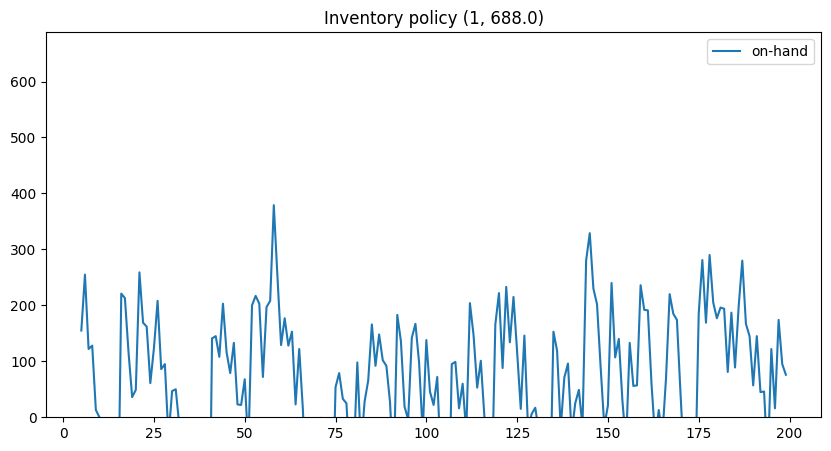

In [48]:
df["on-hand"].plot(title=f"Inventory policy ({R}, {S})", figsize=(10, 5), ylim=(0, S), legend=True)

In [49]:
print("Alpha:", alpha * 100, "%")
SL_alpha = 1 - sum(stockout_cycle) / len(stockout_cycle)
print("Service level:", SL_alpha * 100, "%")
SL_period = 1 - sum(stockout_period) / len(stockout_period)
print("Service level (periods):", SL_period * 100, "%")

Alpha: 95.0 %
Service level: 73.109243697479 %
Service level (periods): 73.5 %
